# Tutorial05 · Spam Message Classification

From text to features to predictions

**Tutor:** Yinghao Zhu · yhzhu99@connect.hku.hk

Turn labelled messages into a text classifier, explain how its inputs are built, and inspect its mistakes.

No NLP background is assumed. Start with the original UCI SMS Spam Collection, see how NLTK splits text into tokens, build word-count and TF–IDF vectors, then use Naive Bayes, logistic regression and KNN. Complete extensions cover regularization, cross-validation, numerical features, LDA and an additive spline model (GAM); they can be studied separately.

## Learning route

1. **Text Classification** — Turn a new message into a spam / ham prediction.
2. **Our Messages and Labels** — Inspect the data and reserve messages for fair evaluation.
3. **Tokenization and Preprocessing** — See how a string becomes a sequence of tokens.
4. **Bag of Words** — Build a vocabulary, then count the words in each message.
5. **TF–IDF** — Weight words using both their counts and their frequency across documents.
6. **Naive Bayes Classification** — Learn which words occur in each class, then classify a new message.
7. **Logistic Regression for Text** — Reuse a familiar classifier with word vectors as inputs.
8. **KNN and Similar Messages** — Inspect the messages that vote on a new prediction.
9. **Regularization for Text Models** (extension) — Should one rare word receive a huge weight?
10. **Cross-Validation with a Pipeline** (extension) — What must be fitted again inside each fold?
11. **Numerical Features from Messages** (extension) — What can we measure before understanding language?
12. **LDA on Numerical Features** (extension) — What changes if we model the features within each class?
13. **GAM: Smooth Numerical Effects** (extension) — Allow curved effects of the log-transformed numerical measurements.
14. **Evaluation and Error Analysis** — Compare choices fairly, inspect mistakes, then evaluate the selected model.

Follow sections 1–8, then go directly to section 14 for the core lesson. Sections 9–13 are complete extensions for instructor selection; evaluation does not depend on them. Each extension uses the setup below and explains its own inputs.

## Learning objectives

- Trace a message through NLTK tokenization, a vocabulary and a word-count matrix.
- Explain TF, document frequency, smoothed IDF and normalization using a small example.
- Train Naive Bayes, logistic regression and KNN with explicit sklearn tools.
- Compare representations and classifiers fairly, then explain false alarms and missed spam.
- In the extensions: explore regularization, leakage-free CV, LDA and GAM on suitable features.

**Prerequisites:** Basic Python and familiarity with classification from lectures. No previous NLP course is needed. Extension chapters briefly reconnect to regularization, cross-validation, LDA and GAM.

**Outcome:** An executed notebook with inspectable text features, model comparisons, representative errors and a justified final decision.

## Setup

Extract the complete student package and keep the notebook beside `experiment.py` and `data/`. Install `requirements.txt`. NLTK’s Treebank tokenizer needs no resource downloads.

The bundled data are the original UCI SMS Spam Collection: [source and citation](https://archive.ics.uci.edu/dataset/228/sms+spam+collection). These are English SMS messages, not full emails. Source details and limitations are in `data/README.md`.

The setup helper loads the original tab-separated file, removes duplicate identities before splitting, and supplies training and validation arrays. Test messages remain reserved for the final cell. The examples below import NLTK and sklearn tools explicitly.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from experiment import Experiment, tokens, numerical_features, metrics

lab = Experiment("data/SMSSpamCollection.txt")
X_train, y_train = lab.X_train.copy(), lab.y_train.copy()
X_val, y_val = lab.X_val.copy(), lab.y_val.copy()
initial = lab.initialize()
print("Original / duplicate / retained:", initial["raw"], initial["duplicates"], initial["unique"])
print("Train / validation / test counts:", initial["counts"])
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})
HAM, SPAM = "#45657e", "#aa613d"

Original / duplicate / retained: 5574 415 5159
Train / validation / test counts: {'train': {'total': 3095, 'ham': 2710, 'spam': 385}, 'validation': {'total': 1032, 'ham': 903, 'spam': 129}, 'test': {'total': 1032, 'ham': 904, 'spam': 128}}


## 1. Text Classification

Turn a new message into a spam / ham prediction.

Text classification assigns a category to a piece of text.

- Our input is a message; its label is ham (normal, 0) or spam (1). Training examples contain both text and a known label.
- Natural language processing (NLP) includes tasks that work with human language. Spam filtering and sentiment classification are two examples.

### One keyword is not enough

Both messages contain “free”, but they need different labels. We want to learn from many words together.

| Message | Label |
| --- | --- |
| Claim your free prize! | Spam |
| Are you free after class? | Ham |

### The route through this tutorial

Message → tokens → numerical features → classifier → predicted label. A vectorizer represents text; a classifier learns how that representation relates to labels.

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [2]:
messages = ["Claim your free prize!", "Are you free after class?"]
for message in messages:
    print(message, "→ keyword rule:", "spam" if "free" in message.lower() else "ham")

Claim your free prize! → keyword rule: spam
Are you free after class? → keyword rule: spam


### Try, predict, explain

Add one normal message that contains “free”. Explain why this rule cannot distinguish the messages.

In [3]:
messages = ["Claim your free prize!", "Are you free after class?"]
for message in messages:
    print("Keyword prediction:", "spam" if "free" in message.lower() else "ham", "|", message)

Keyword prediction: spam | Claim your free prize!
Keyword prediction: spam | Are you free after class?


**Takeaway:** The task is to learn a mapping from messages to labels using examples.

First, inspect the labelled messages we will learn from.

## 2. Our Messages and Labels

Inspect the data and reserve messages for fair evaluation.

Each row is one English SMS message with a known label.

- The original UCI SMS Spam Collection contains 5,574 messages. These are short SMS texts, without email headers or subjects.
- Remove duplicate message identities before splitting. We retain 5,159 messages and use stratified 60 / 20 / 20 splits.
- Train fits the model and vocabulary. Validation helps compare choices. Test is reserved for one final evaluation.

### Look at both classes

Only about 12% of the retained messages are spam. A filter that always says ham can have high accuracy while catching no spam.

| Split | Messages | Use |
| --- | --- | --- |
| Train | 3,095 | Learn vocabulary, IDF and model |
| Validation | 1,032 | Compare choices and inspect errors |
| Test | 1,032 | Final evaluation after choosing |

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [4]:
for text, label in zip(X_train[:5], y_train[:5]):
    print("spam" if label else "ham", "|", text)
baseline = metrics(y_val, np.zeros(len(y_val)))
print("Always-ham accuracy:", round(baseline["accuracy"], 3))
print("Always-ham recall:", baseline["recall"])

ham | No management puzzeles.
ham | Awesome, plan to get here any time after like  &lt;#&gt; , I'll text you details in a wee bit
ham | I'm outside islands, head towards hard rock and you'll run into me
ham | Tmrw. Im finishing 9 doors
ham | Yup, no need. I'll jus wait 4 e rain 2 stop.
Always-ham accuracy: 0.875
Always-ham recall: 0.0


### Try, predict, explain

Find one ham and one spam message in the table. Identify useful words and explain why accuracy alone may mislead.

In [5]:
print("Training / validation:", len(X_train), len(X_val))
print("Training spam proportion:", y_train.mean())
baseline = metrics(y_val, np.zeros(len(y_val)))
print("Always-ham accuracy:", baseline["accuracy"])
print("Always-ham recall:", baseline["recall"])

Training / validation: 3095 1032
Training spam proportion: 0.12439418416801293
Always-ham accuracy: 0.875
Always-ham recall: 0.0


**Takeaway:** Know the labels and class balance before fitting a classifier.

The messages are strings. Next, we need to decide how to split them into units.

## 3. Tokenization and Preprocessing

See how a string becomes a sequence of tokens.

Tokenization splits text into units that we can count.

- NLTK (Natural Language Toolkit) provides tokenizers. We use TreebankWordTokenizer to split English words and punctuation without downloading language resources.
- For this baseline, lowercase the text and retain alphanumeric tokens. Use exactly the same preprocessing for training and new messages.

### Follow one message

Original: Congratulations! Claim your FREE prize now!

Lowercase: congratulations! claim your free prize now!

NLTK tokens: ["congratulations", "!", "claim", "your", "free", "prize", "now", "!"]

Retained tokens: ["congratulations", "claim", "your", "free", "prize", "now"]

### Preprocessing is a choice

Lowercasing merges “FREE” and “free”. Discarding punctuation also discards evidence such as “!!!”. URLs, currency and contractions need care; this small baseline does not preserve everything.

Stopword removal and stemming are additional choices, not compulsory steps. Removing “not”, for example, can change a sentiment task. Try stemming below and inspect what it changes.

English tokenization does not automatically solve Chinese word segmentation. This tutorial uses English messages.

[NLTK tokenizers](https://www.nltk.org/api/nltk.tokenize.html)

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [6]:
from nltk.tokenize import TreebankWordTokenizer

text = "Congratulations! Claim your FREE prize now!"
raw_tokens = TreebankWordTokenizer().tokenize(text.lower())
kept_tokens = [word for word in raw_tokens if word.isalnum()]
print("NLTK tokens:", raw_tokens)
print("Retained tokens:", kept_tokens)

NLTK tokens: ['congratulations', '!', 'claim', 'your', 'free', 'prize', 'now', '!']
Retained tokens: ['congratulations', 'claim', 'your', 'free', 'prize', 'now']


### Try, predict, explain

Try “I am not winning £1000!!!”. Inspect what is retained, discarded and stemmed. Which changes might remove useful evidence?

In [7]:
from nltk.tokenize import TreebankWordTokenizer
from nltk.stem import PorterStemmer

text = "Congratulations! Claim your FREE prize now!"
raw = TreebankWordTokenizer().tokenize(text.lower())
kept = [word for word in raw if word.isalnum()]
print("NLTK tokens:", raw)
print("Retained tokens:", kept)
stemmer = PorterStemmer()
print("Optional stemming:", [(word, stemmer.stem(word)) for word in kept])

NLTK tokens: ['congratulations', '!', 'claim', 'your', 'free', 'prize', 'now', '!']
Retained tokens: ['congratulations', 'claim', 'your', 'free', 'prize', 'now']
Optional stemming: [('congratulations', 'congratul'), ('claim', 'claim'), ('your', 'your'), ('free', 'free'), ('prize', 'prize'), ('now', 'now')]


**Takeaway:** A tokenizer defines what a “word” means to this model.

A sequence of tokens still has variable length. Bag of Words gives every message the same columns.

## 4. Bag of Words

Build a vocabulary, then count the words in each message.

Bag of Words represents a message as a vector of word counts.

- There are multiple ways to extract features from text. We start with Bag of Words (BoW), implemented by sklearn’s CountVectorizer.
- Create a vocabulary from the training documents. Then count each vocabulary word in each document: one message per row, one word per column.
- The “bag” ignores grammar and word order. Reordering words leaves the count vector unchanged.

### Two sentences, one shared vocabulary

Sentence 1: “The cat sat on the mat.” Sentence 2: “The dog ate the cat.”

Using sklearn’s alphabetical column order, the vocabulary is [ate, cat, dog, mat, on, sat, the].

| Message | ate | cat | dog | mat | on | sat | the |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Sentence 1 | 0 | 1 | 0 | 1 | 1 | 1 | 2 |
| Sentence 2 | 1 | 1 | 1 | 0 | 0 | 0 | 2 |

### Read the matrix

The first row has a 2 in the “the” column because “the” occurs twice. Every row has seven values, even when most are zero.

fit_transform learns the vocabulary and counts the training documents. transform uses those same columns for a new message. Unseen words are ignored.

Read get_feature_names_out() alongside the matrix; vector positions only make sense with their column names. Real matrices remain sparse: most entries are zero.

[CountVectorizer documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from experiment import tokens

messages = ["The cat sat on the mat.", "The dog ate the cat."]
vectorizer = CountVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False)
X = vectorizer.fit_transform(messages)
print("Vocabulary:", vectorizer.get_feature_names_out())
print("Count matrix:\n", X.toarray())
print("New message:", vectorizer.transform(["The cat ate lunch."]).toarray())

Vocabulary: ['ate' 'cat' 'dog' 'mat' 'on' 'sat' 'the']
Count matrix:
 [[0 1 0 1 1 1 2]
 [1 1 1 0 0 0 2]]
New message: [[1 1 0 0 0 0 1]]


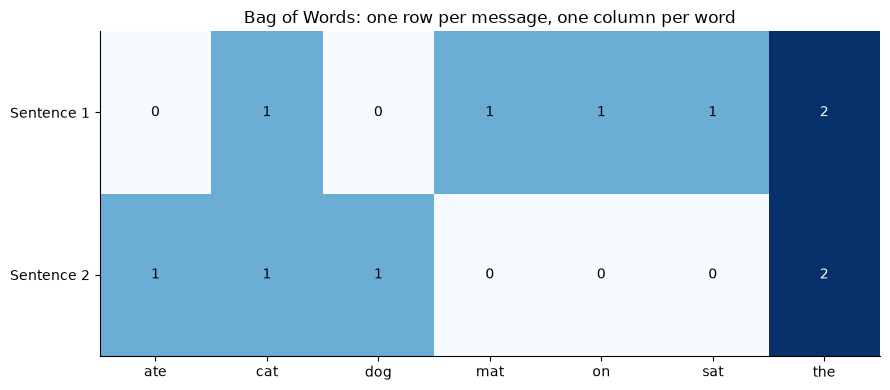

In [9]:
fig, ax = plt.subplots()
matrix = X.toarray()
ax.imshow(matrix, cmap="Blues", aspect="auto")
ax.set_xticks(range(matrix.shape[1]), vectorizer.get_feature_names_out())
ax.set_yticks([0, 1], ["Sentence 1", "Sentence 2"])
for (row, col), value in np.ndenumerate(matrix):
    ax.text(col, row, str(value), ha="center", va="center", color="white" if value == 2 else "black")
ax.set_title("Bag of Words: one row per message, one column per word")
plt.tight_layout()
plt.show()

### Try, predict, explain

Repeat a word, reorder a sentence, then add an unseen word. Predict which columns change before running the code.

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from experiment import tokens

toy = ["free prize now", "are you free after class", "win a prize prize"]
vectorizer = CountVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False)
X = vectorizer.fit_transform(toy)
print("Vocabulary:", vectorizer.get_feature_names_out())
print("Count matrix:\n", X.toarray())
for message in ["free prize", "prize free", "free meeting tomorrow"]:
    print(message, "→", vectorizer.transform([message]).toarray())

Vocabulary: ['a' 'after' 'are' 'class' 'free' 'now' 'prize' 'win' 'you']
Count matrix:
 [[0 0 0 0 1 1 1 0 0]
 [0 1 1 1 1 0 0 0 1]
 [1 0 0 0 0 0 2 1 0]]
free prize → [[0 0 0 0 1 0 1 0 0]]
prize free → [[0 0 0 0 1 0 1 0 0]]
free meeting tomorrow → [[0 0 0 0 1 0 0 0 0]]


**Takeaway:** The training vocabulary fixes the meaning of every column.

Counts are usable features, but a word shared by almost every message may deserve less weight.

## 5. TF–IDF

Weight words using both their counts and their frequency across documents.

TF–IDF reduces the weight of words that occur in many documents.

- TF (term frequency) is the word count in the current document here. DF (document frequency) counts documents containing the word, once per document.
- IDF (inverse document frequency) is larger for words that appear in fewer training documents. Multiply TF by IDF to obtain a weight.
- TF–IDF uses no class labels. A rare word is not automatically evidence of spam. The classifier learns how features relate to labels.

### Start from three documents

1. “claim your prize”   2. “check your timetable”   3. “send your notes”

“your” appears in all three documents. “prize” appears in one. In document 1, both words have TF = 1.

| Word | TF in document 1 | DF | Smoothed IDF | TF × IDF |
| --- | --- | --- | --- | --- |
| your | 1 | 3 | log(4 / 4) + 1 = 1.000 | 1.000 |
| prize | 1 | 1 | log(4 / 2) + 1 = 1.693 | 1.693 |

### From weights to sklearn’s default output

sklearn uses natural log and the smoothed IDF shown below. The +1 terms avoid problematic zero denominators and keep weights positive.

Document 1 has nonzero weights [claim: 1.693, prize: 1.693, your: 1.000]. Its L2 norm is √(1.693² + 1.693² + 1²) ≈ 2.594.

By default, TfidfVectorizer divides the row by that norm: [claim: 0.652, prize: 0.652, your: 0.385]. Set norm=None to inspect the unnormalized weights.

Normalization removes pure scale differences from repeating an entire message. Unknown words are still ignored; an all-unknown message remains a zero vector.

### Calculation

$$\mathrm{idf}_j=\log\frac{1+n}{1+\mathrm{df}_j}+1,\quad v_j=\mathrm{TF}_j\,\mathrm{idf}_j,\quad x_j=\frac{v_j}{\sqrt{\sum_k v_k^2}}$$

- $n$: number of training documents
- $\mathrm{df}_j$: training documents containing word j
- $v_j$: weight before normalization
- $x_j$: normalized feature; a zero row stays zero

[TfidfVectorizer documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from experiment import tokens

toy = ["claim your prize", "check your timetable", "send your notes"]
raw = TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, norm=None)
weighted = raw.fit_transform(toy).toarray()
print("Vocabulary:", raw.get_feature_names_out())
print("IDF:", np.round(raw.idf_, 3))
print("TF × IDF:\n", np.round(weighted, 3))
norms = np.linalg.norm(weighted, axis=1, keepdims=True)
normalized = np.divide(weighted, norms, out=np.zeros_like(weighted), where=norms != 0)
default = TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False)
print("Normalized TF–IDF:\n", np.round(default.fit_transform(toy).toarray(), 3))
print("Manual normalization matches sklearn:", np.allclose(normalized, default.transform(toy).toarray()))

Vocabulary: ['check' 'claim' 'notes' 'prize' 'send' 'timetable' 'your']
IDF: [1.693 1.693 1.693 1.693 1.693 1.693 1.   ]
TF × IDF:
 [[0.    1.693 0.    1.693 0.    0.    1.   ]
 [1.693 0.    0.    0.    0.    1.693 1.   ]
 [0.    0.    1.693 0.    1.693 0.    1.   ]]
Normalized TF–IDF:
 [[0.    0.652 0.    0.652 0.    0.    0.385]
 [0.652 0.    0.    0.    0.    0.652 0.385]
 [0.    0.    0.652 0.    0.652 0.    0.385]]
Manual normalization matches sklearn: True


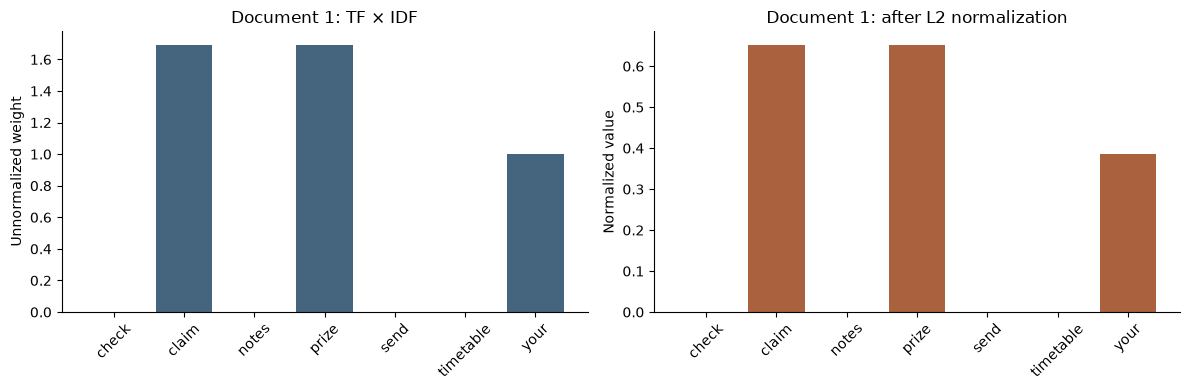

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
names = raw.get_feature_names_out()
axes[0].bar(names, weighted[0], color=HAM)
axes[0].set(title="Document 1: TF × IDF", ylabel="Unnormalized weight")
axes[1].bar(names, normalized[0], color=SPAM)
axes[1].set(title="Document 1: after L2 normalization", ylabel="Normalized value")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Try, predict, explain

Add “prize” to more training documents. Predict how its IDF changes. Then repeat an entire message and compare its normalized vectors.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from experiment import tokens

toy = ["claim your prize", "check your timetable", "send your notes"]
for documents in [toy, toy + ["your prize"]]:
    vectorizer = TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False)
    vectorizer.fit(documents)
    print("IDF:", dict(zip(vectorizer.get_feature_names_out(), np.round(vectorizer.idf_, 3))))
print("Repeated document:")
print(np.round(vectorizer.transform(["claim your prize", "claim your prize claim your prize"]).toarray(), 3))

IDF: {'check': np.float64(1.693), 'claim': np.float64(1.693), 'notes': np.float64(1.693), 'prize': np.float64(1.693), 'send': np.float64(1.693), 'timetable': np.float64(1.693), 'your': np.float64(1.0)}
IDF: {'check': np.float64(1.916), 'claim': np.float64(1.916), 'notes': np.float64(1.916), 'prize': np.float64(1.511), 'send': np.float64(1.916), 'timetable': np.float64(1.916), 'your': np.float64(1.0)}
Repeated document:
[[0.    0.727 0.    0.573 0.    0.    0.379]
 [0.    0.727 0.    0.573 0.    0.    0.379]]


**Takeaway:** Fit vocabulary and IDF on training text; reuse both when transforming new messages.

We now have numerical inputs. Next, learn how the words support each class.

## 6. Naive Bayes Classification

Learn which words occur in each class, then classify a new message.

Naive Bayes combines the class proportions with word evidence.

- The prior is the class proportion. The likelihood describes how frequently a word occurs among tokens from that class.
- Multinomial Naive Bayes uses word counts. “Naive” means treating word occurrences as conditionally independent given the class; real language does not fully satisfy this assumption.
- Additive smoothing gives every vocabulary word a positive count in each class. With alpha = 1, a word absent from a class does not force its whole message likelihood to zero.

### Count a tiny labelled training set



| Label | Message |
| --- | --- |
| Ham | meet after class |
| Ham | meet for lunch |
| Spam | claim your prize |
| Spam | win your prize |

### Classify “claim prize” by hand

There are nine vocabulary words and six observed tokens in each class. With alpha = 1, each class denominator is 6 + 9 = 15. Both class priors are 1/2.

| Word | Ham count | Spam count | P(word | ham) | P(word | spam) |
| --- | --- | --- | --- | --- |
| claim | 0 | 1 | 1/15 | 2/15 |
| prize | 0 | 2 | 1/15 | 3/15 |

### Compare the two class scores

Ham: (1/2) × (1/15) × (1/15) = 1/450. Spam: (1/2) × (2/15) × (3/15) = 6/450.

Normalize the scores: P(spam | “claim prize”) = 6 / (1 + 6) ≈ 0.857. sklearn computes this in log space to avoid multiplying many tiny values.

A repeated word contributes repeatedly. The model does not understand grammar, and its predicted probability need not be well calibrated.

### Now use the real dataset

First learn CountVectorizer on training messages, then fit MultinomialNB on the resulting matrix. Validation messages reuse the learned vocabulary.

After inspecting the count model, replace counts with TF–IDF while keeping NB fixed. sklearn accepts nonnegative TF–IDF weights, although they are not literal multinomial counts; compare the result empirically.

The comparison uses average precision (AP), which summarizes precision–recall ranking across thresholds; higher is better. We inspect individual mistakes in the evaluation chapter.

### Calculation

$$P(w_j\mid c)=\frac{N_{cj}+\alpha}{\sum_k N_{ck}+\alpha V},\qquad P(c\mid\mathbf x)\propto P(c)\prod_j P(w_j\mid c)^{x_j}$$

- $N_{cj}$: count of word j among training tokens in class c
- $V$: training vocabulary size
- $\alpha$: additive smoothing strength; 1 in the worked example
- $x_j$: word count in the new message

[MultinomialNB documentation](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html)

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from experiment import tokens

toy = ["meet after class", "meet for lunch", "claim your prize", "win your prize"]
vectorizer = CountVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False)
X_toy = vectorizer.fit_transform(toy)
classifier = MultinomialNB(alpha=1)
classifier.fit(X_toy, [0, 0, 1, 1])
print("Vocabulary:", vectorizer.get_feature_names_out())
print("Tokens per class:", classifier.feature_count_.sum(axis=1))
print("P(spam | claim prize):", classifier.predict_proba(vectorizer.transform(["claim prize"]))[0, 1])

# Connect representation and classifier in one pipeline for real messages.
model = Pipeline([
    ("vectorizer", CountVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
    ("classifier", MultinomialNB(alpha=1))
])
model.fit(X_train, y_train)
probability = model.predict_proba(X_val)[:, 1]
print("NB validation:", metrics(y_val, probability))
print("New message:", model.predict(["Claim your free prize now!"]))

Vocabulary: ['after' 'claim' 'class' 'for' 'lunch' 'meet' 'prize' 'win' 'your']
Tokens per class: [6. 6.]
P(spam | claim prize): 0.8571428571428573
NB validation: {'accuracy': 0.9844961240310077, 'precision': 0.9669421487603306, 'recall': 0.9069767441860465, 'f1': 0.9359999999999999, 'confusion': [[899, 4], [12, 117]], 'false_positive_rate': 0.004429678848283499, 'log_loss': 0.10522727945776685, 'average_precision': 0.9518084445908659, 'roc_auc': 0.9725462927193592}
New message: [1]


### Try, predict, explain

Keep NB fixed and compare counts with TF–IDF. Inspect a normal message containing “free”: which other words and prior evidence affect its prediction?

In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from experiment import tokens

for Vectorizer in [CountVectorizer, TfidfVectorizer]:
    model = Pipeline([
        ("vectorizer", Vectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", MultinomialNB(alpha=1))
    ])
    model.fit(X_train, y_train)
    result = metrics(y_val, model.predict_proba(X_val)[:, 1])
    print("NB representation comparison:", Vectorizer.__name__, "AP:", round(result["average_precision"], 3), "recall:", round(result["recall"], 3))

NB representation comparison: CountVectorizer AP: 0.952 recall: 0.907
NB representation comparison: TfidfVectorizer AP: 0.943 recall: 0.682


**Takeaway:** The vectorizer creates features; Naive Bayes learns class-specific word evidence.

The same word vectors can be inputs to other classifiers you have studied.

## 7. Logistic Regression for Text

Reuse a familiar classifier with word vectors as inputs.

Logistic regression learns a weight for each word feature.

- The classifier is familiar from earlier tutorials; the new part is the input matrix. Each column now represents a word instead of a measurement such as pixel intensity.
- Positive weights push towards spam; negative weights push towards ham. For one message, the contribution is weight × feature value. An absent word contributes zero.
- Hold the representation fixed when comparing LR with NB. A larger word weight alone does not guarantee a larger contribution, especially with TF–IDF.

### Replace the classifier, keep the inputs

The code below changes MultinomialNB to LogisticRegression. The preprocessing, training split and vectorizer stay the same.

Read the contributions for one message, then change a word. This applies logistic regression to text without repeating its optimization derivation.

### Formula recap

$$z=b+\sum_j w_jx_j,\qquad p=\frac{1}{1+e^{-z}}$$

- $w_jx_j$: word j’s contribution to this message
- $b$: intercept
- $p$: model-estimated spam probability

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from experiment import tokens

model = Pipeline([
    ("vectorizer", CountVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
    ("classifier", LogisticRegression(C=1, solver="liblinear", max_iter=1000, random_state=3612))
])
model.fit(X_train, y_train)
print("LR validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])
names = model.named_steps["vectorizer"].get_feature_names_out()
weights = model.named_steps["classifier"].coef_[0]
message = "Congratulations! Claim your free prize now!"
values = model.named_steps["vectorizer"].transform([message]).toarray()[0]
for j in np.flatnonzero(values):
    print(names[j], "feature:", values[j], "weight:", round(weights[j], 3), "contribution:", round(values[j] * weights[j], 3))

LR validation AP: 0.9532468079133766
claim feature: 1 weight: 1.289 contribution: 1.289
congratulations feature: 1 weight: 0.138 contribution: 0.138
free feature: 1 weight: 1.008 contribution: 1.008
now feature: 1 weight: 0.952 contribution: 0.952
prize feature: 1 weight: 0.939 contribution: 0.939
your feature: 1 weight: 0.732 contribution: 0.732


### Try, predict, explain

Replace one word in a message and inspect the change in its contribution and prediction. Keep the representation fixed when comparing with NB.

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from experiment import tokens

model = Pipeline([
    ("vectorizer", CountVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
    ("classifier", LogisticRegression(C=1, solver="liblinear", max_iter=1000, random_state=3612))
])
model.fit(X_train, y_train)
for text in ["Claim your free prize now", "Are you free after class"]:
    print("LR prediction:", text, "→", round(model.predict_proba([text])[0, 1], 3))

LR prediction: Claim your free prize now → 0.657
LR prediction: Are you free after class → 0.029


**Takeaway:** Existing classifiers can work with text once we provide a numerical representation.

Another approach is to compare a new message with similar training messages.

## 8. KNN and Similar Messages

Inspect the messages that vote on a new prediction.

KNN predicts from the labels of nearby training messages.

- Use TF–IDF vectors and cosine distance to compare their directions. A small distance means similar word-weight patterns, not necessarily similar meaning.
- KNN stores the training examples. With uniform voting, its spam score is the proportion of spam among the k neighbours.
- Inspect the actual neighbours. A message with no known words has a zero vector, so word-based similarity offers little useful evidence.

### Change only one choice at a time

For a model comparison, use TF–IDF for NB, LR and KNN. For a KNN experiment, keep the representation fixed and change k.

A small k can be sensitive to a single example. A large k may include less relevant messages and favour the majority class.

### Formula recap

$$\hat p(\mathbf x)=\frac{1}{k}\sum_{i\in N_k(\mathbf x)}y_i$$

- $k$: number of neighbours
- $N_k(\mathbf x)$: nearest training messages
- $y_i$: 1 for spam, 0 for ham

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from experiment import tokens

model = Pipeline([
    ("vectorizer", TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
    ("classifier", KNeighborsClassifier(n_neighbors=5, metric="cosine", algorithm="brute"))
])
model.fit(X_train, y_train)
text = "claim your free prize now"
vector = model.named_steps["vectorizer"].transform([text])
distances, indices = model.named_steps["classifier"].kneighbors(vector)
for distance, index in zip(distances[0], indices[0]):
    print(round(distance, 3), "spam" if y_train[index] else "ham", "|", X_train[index])
print("Spam vote:", model.predict_proba([text])[0, 1])

0.549 spam | You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327
0.583 ham | Are you free now?can i call now?
0.611 spam | Hi, this is Mandy Sullivan calling from HOTMIX FM...you are chosen to receive £5000.00 in our Easter Prize draw.....Please telephone 09041940223 to claim before 29/03/05 or your prize will be transferred to someone else....
0.618 spam | Win a £1000 cash prize or a prize worth £5000
0.623 spam | URGENT This is our 2nd attempt to contact U. Your £900 prize from YESTERDAY is still awaiting collection. To claim CALL NOW 09061702893
Spam vote: 0.8


### Try, predict, explain

Compare k = 3 with k = 15. Read the additional neighbours and explain the change in the vote.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from experiment import tokens

model = Pipeline([
    ("vectorizer", TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
    ("classifier", KNeighborsClassifier(n_neighbors=5, metric="cosine", algorithm="brute"))
])
model.fit(X_train, y_train)
text = "claim your free prize now"
distance, index = model.named_steps["classifier"].kneighbors(model[:-1].transform([text]))
for d, i in zip(distance[0], index[0]):
    print(round(d, 3), "spam" if y_train[i] else "ham", X_train[i])
print("Spam vote:", model.predict_proba([text])[0, 1])

0.549 spam You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327
0.583 ham Are you free now?can i call now?
0.611 spam Hi, this is Mandy Sullivan calling from HOTMIX FM...you are chosen to receive £5000.00 in our Easter Prize draw.....Please telephone 09041940223 to claim before 29/03/05 or your prize will be transferred to someone else....
0.618 spam Win a £1000 cash prize or a prize worth £5000
0.623 spam URGENT This is our 2nd attempt to contact U. Your £900 prize from YESTERDAY is still awaiting collection. To claim CALL NOW 09061702893
Spam vote: 0.8


**Takeaway:** The representation and distance determine which messages KNN considers similar.

You can go directly to evaluation. The next five chapters extend model selection and numerical-feature modelling.

## 9. Regularization for Text Models

**Extension — may be studied separately from the core route.**

Should one rare word receive a huge weight?

With thousands of word features, rare training coincidences can receive large weights. This extension returns to the LR model and changes only its penalty strength.

- Thousands of word columns can capture accidental associations. Compare training and validation performance while keeping the representation fixed.
- The L2 penalty shrinks weights towards 0. In sklearn, smaller C means a stronger penalty.
- Too strong: the model underfits. Too weak: it memorizes training noise. Watch the gap between training and validation.

### Read the experiment

Average precision (AP) summarizes the precision–recall ranking across thresholds; higher is better. The code prints training AP, validation AP and the L2 norm of the weights.

Large training improvements without corresponding held-out improvements suggest overfitting. A particular dataset need not show a textbook U-shaped validation curve.

### Formula recap

$$C\downarrow\ \Rightarrow\ \text{stronger L2 penalty}\ \Rightarrow\ \text{smaller fitted weights}$$

- $C$: inverse regularization strength in sklearn

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [20]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from experiment import tokens

for C in [.001, .01, .1, 1, 10]:
    model = Pipeline([
        ("vectorizer", CountVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", LogisticRegression(C=C, solver="liblinear", max_iter=1000, random_state=3612))
    ])
    model.fit(X_train, y_train)
    train = metrics(y_train, model.predict_proba(X_train)[:, 1])["average_precision"]
    val = metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"]
    norm = np.linalg.norm(model.named_steps["classifier"].coef_)
    print(f"C={C:g}, weight norm={norm:.3f}, train AP={train:.3f}, validation AP={val:.3f}")

C=0.001, weight norm=0.494, train AP=0.687, validation AP=0.676


C=0.01, weight norm=1.790, train AP=0.940, validation AP=0.922


C=0.1, weight norm=4.922, train AP=0.978, validation AP=0.944


C=1, weight norm=11.822, train AP=0.998, validation AP=0.953


C=10, weight norm=22.375, train AP=0.998, validation AP=0.955


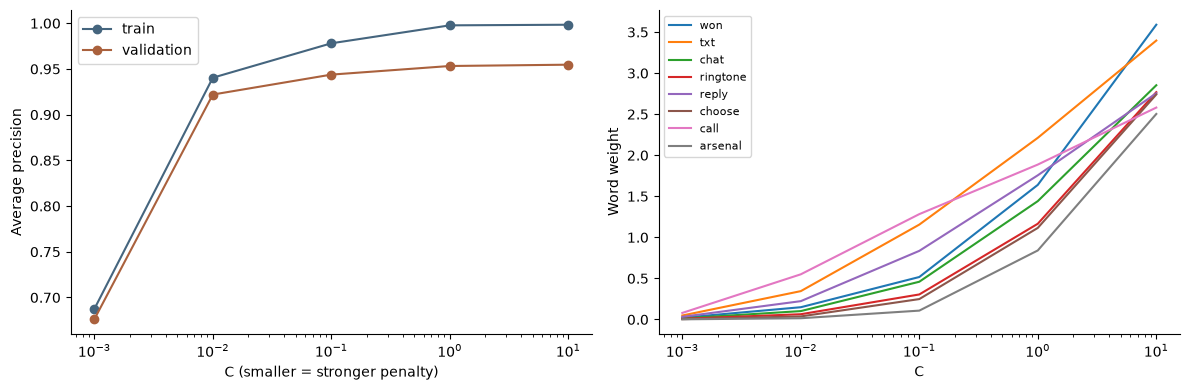

In [21]:
path_result = lab.regularization({"representation": "count"})
Cs = [row["C"] for row in path_result["rows"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for split, color in [("train", HAM), ("validation", SPAM)]:
    axes[0].semilogx(Cs, [row[split]["average_precision"] for row in path_result["rows"]], "o-", label=split, color=color)
axes[0].set(xlabel="C (smaller = stronger penalty)", ylabel="Average precision")
axes[0].legend()
for item in path_result["paths"]:
    axes[1].semilogx(Cs, item["weights"], label=item["word"])
axes[1].set(xlabel="C", ylabel="Word weight")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Try, predict, explain

Which C gives the best validation AP? Did larger weights help?

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from experiment import tokens

for C in [.001, .01, .1, 1, 10]:
    model = Pipeline([
        ("vectorizer", CountVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", LogisticRegression(C=C, solver="liblinear", max_iter=1000, random_state=3612))
    ])
    model.fit(X_train, y_train)
    train = metrics(y_train, model.predict_proba(X_train)[:, 1])["average_precision"]
    val = metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"]
    norm = np.linalg.norm(model.named_steps["classifier"].coef_)
    print(f"C={C:g}, weight norm={norm:.3f}, train AP={train:.3f}, validation AP={val:.3f}")

C=0.001, weight norm=0.494, train AP=0.687, validation AP=0.676


C=0.01, weight norm=1.790, train AP=0.940, validation AP=0.922


C=0.1, weight norm=4.922, train AP=0.978, validation AP=0.944


C=1, weight norm=11.822, train AP=0.998, validation AP=0.953


C=10, weight norm=22.375, train AP=0.998, validation AP=0.955


**Takeaway:** C controls how the model is fitted; the threshold controls decisions afterwards. They are different knobs.

## 10. Cross-Validation with a Pipeline

**Extension — may be studied separately from the core route.**

What must be fitted again inside each fold?

Cross-validation compares choices across several held-out training folds. Every learned step, including the vocabulary and IDF, belongs inside the pipeline.

- Split the training data into 5 folds. Fit on 4, score the 5th, rotate, then average.
- The vocabulary and IDF are learned too. Refit them inside every fold, or held-out words leak into training.
- Pick the C with the best mean score, then refit on all training data.

### What is fitted inside one fold?

Four training folds → learn vocabulary, IDF and LR weights. Fifth fold → transform with those fitted steps and compute AP. Rotate the held-out fold, then average.

GridSearchCV clones and refits the entire Pipeline for each candidate and fold. Fitting a vectorizer on all messages before CV would allow held-out text to influence the representation. The final test set is never involved.

### Formula recap

$$\mathrm{CV}(C)=\frac{1}{5}\sum_{f=1}^{5}\mathrm{AP}_f(C)$$

- $f$: the held-out fold
- $\mathrm{AP}_f(C)$: average precision on fold f; the pipeline is fitted without it
- $\mathrm{AP}$: area-like summary of the precision–recall curve

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from experiment import tokens

model = Pipeline([
    ("vectorizer", TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
    ("classifier", LogisticRegression(solver="liblinear", max_iter=1000, random_state=3612))
])
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=3612)
search = GridSearchCV(model, {"classifier__C": [.01, .1, 1, 10]}, cv=folds, scoring="average_precision")
search.fit(X_train, y_train)
print("Selected C:", search.best_params_["classifier__C"])
for params, mean, std in zip(search.cv_results_["params"], search.cv_results_["mean_test_score"], search.cv_results_["std_test_score"]):
    print(params, "mean AP:", round(mean, 3), "SD:", round(std, 3))

Selected C: 10
{'classifier__C': 0.01} mean AP: 0.921 SD: 0.021
{'classifier__C': 0.1} mean AP: 0.941 SD: 0.018
{'classifier__C': 1} mean AP: 0.955 SD: 0.017
{'classifier__C': 10} mean AP: 0.96 SD: 0.015


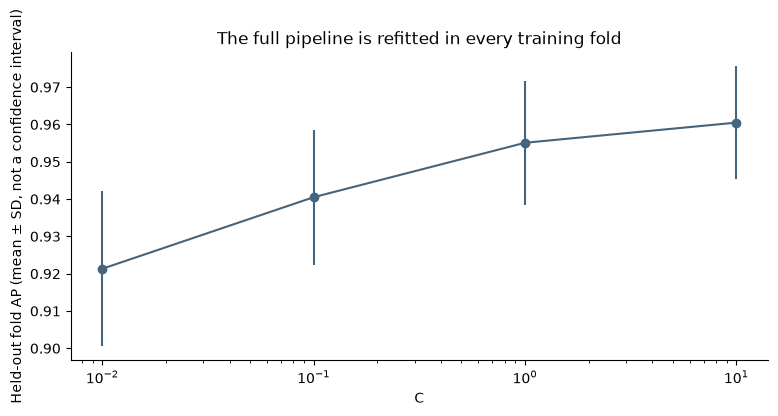

In [24]:
means = search.cv_results_["mean_test_score"]
std = search.cv_results_["std_test_score"]
Cs = [p["classifier__C"] for p in search.cv_results_["params"]]
plt.errorbar(Cs, means, yerr=std, fmt="o-", color=HAM)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Held-out fold AP (mean ± SD, not a confidence interval)")
plt.title("The full pipeline is refitted in every training fold")
plt.show()

### Try, predict, explain

Why can the vocabulary size differ between folds, and why is that correct?

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from experiment import tokens

model = Pipeline([
    ("vectorizer", TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
    ("classifier", LogisticRegression(solver="liblinear", max_iter=1000, random_state=3612))
])
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=3612)
search = GridSearchCV(model, {"classifier__C": [.01, .1, 1, 10]}, cv=folds, scoring="average_precision")
search.fit(X_train, y_train)
print("Selected C:", search.best_params_["classifier__C"])
for params, mean, std in zip(search.cv_results_["params"], search.cv_results_["mean_test_score"], search.cv_results_["std_test_score"]):
    print(params, "mean AP:", round(mean, 3), "SD:", round(std, 3))

Selected C: 10
{'classifier__C': 0.01} mean AP: 0.921 SD: 0.021
{'classifier__C': 0.1} mean AP: 0.941 SD: 0.018
{'classifier__C': 1} mean AP: 0.955 SD: 0.017
{'classifier__C': 10} mean AP: 0.96 SD: 0.015


**Takeaway:** Leakage-free CV gives a fair choice of C. Only the test set gives the final, unbiased number.

## 11. Numerical Features from Messages

**Extension — may be studied separately from the core route.**

What can we measure before understanding language?

Word vectors are one representation. For the LDA and GAM extensions, we instead measure five properties of each message.

- Measure characters, retained NLTK tokens, links, digits and exclamation marks.
- Spam tends to be longer and to contain more digits (prices, phone numbers), but the two classes overlap.
- Counts are skewed, so take log(1+x), then standardize with the training mean and standard deviation.
- Five numbers lose most of the meaning: very different messages can share the same counts.

### A different modelling branch

These five features discard word identity. LDA and GAM below use this same numerical representation; compare them with numerical LR, rather than attributing differences from text models solely to the classifier.

### Formula recap

$$u_j=\log(1+x_j),\qquad z_j=\frac{u_j-\mu_j}{s_j}$$

- $x_j$: raw count, e.g. number of digits
- $\mu_j,\ s_j$: mean and SD from training data only
- $z_j$: the value the model sees

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from experiment import numerical_features

texts = ["Are you free at 8?", "WIN £1000! Visit https://example.org now!!!"]
print("Characters, words, links, digits, exclamations:")
print(numerical_features(texts))
model = Pipeline([
    ("features", FunctionTransformer(numerical_features)),
    ("log", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler()),
    ("classifier", LogisticRegression(solver="liblinear", max_iter=1000, random_state=3612))
])
model.fit(X_train, y_train)
print("Numerical baseline AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

Characters, words, links, digits, exclamations:
[[18.  5.  0.  1.  0.]
 [43.  4.  1.  4.  4.]]
Numerical baseline AP: 0.9453045987771983


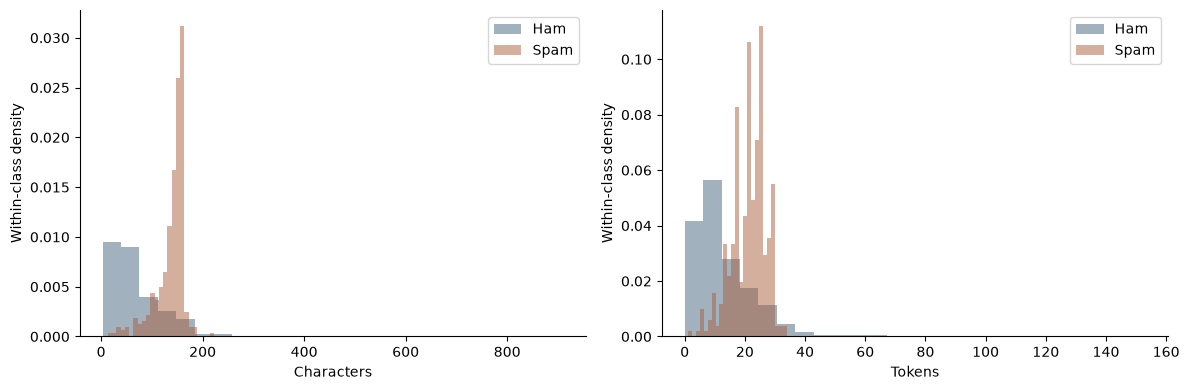

In [27]:
values = numerical_features(X_train)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for j, ax in enumerate(axes):
    for label, color in [(0, HAM), (1, SPAM)]:
        ax.hist(values[y_train == label, j], bins=25, density=True, alpha=.5, color=color, label="Ham" if label == 0 else "Spam")
    ax.set(xlabel=["Characters", "Tokens"][j], ylabel="Within-class density")
    ax.legend()
plt.tight_layout()
plt.show()

### Try, predict, explain

Write two very different messages with the same five numbers. What can this representation not see?

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from experiment import numerical_features

texts = ["Are you free at 8?", "WIN £1000! Visit https://example.org now!!!"]
print("Characters, words, links, digits, exclamations:")
print(numerical_features(texts))
model = Pipeline([
    ("features", FunctionTransformer(numerical_features)),
    ("log", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler()),
    ("classifier", LogisticRegression(solver="liblinear", max_iter=1000, random_state=3612))
])
model.fit(X_train, y_train)
print("Numerical baseline AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

Characters, words, links, digits, exclamations:
[[18.  5.  0.  1.  0.]
 [43.  4.  1.  4.  4.]]
Numerical baseline AP: 0.9453045987771983


**Takeaway:** Every representation keeps some evidence and throws the rest away.

## 12. LDA on Numerical Features

**Extension — may be studied separately from the core route.**

What changes if we model the features within each class?

LDA models the feature distribution within each class. We apply it to the five numerical features rather than sparse word counts.

- Assume each class is Gaussian, with its own mean and a shared covariance.
- A shared covariance makes the boundary linear, like logistic regression, but it is reached differently.
- The class prior (88% ham) moves the boundary towards the rarer spam class.
- We use the five numerical features; a Gaussian model does not suit 2,500 sparse word counts.

### Same inputs, different assumptions

The code fits numerical LR and LDA on the same split and features. The illustration below shows two dimensions, while evaluation uses all five.

Gaussian class distributions are an approximation for these transformed counts. Shared covariance produces a linear decision boundary; shrinkage stabilizes its estimation.

### Formula recap

$$\log\frac{P(\text{spam}\mid\mathbf x)}{P(\text{ham}\mid\mathbf x)}=(\boldsymbol\mu_1-\boldsymbol\mu_0)^\top\Sigma^{-1}\mathbf x+b$$

- $\boldsymbol\mu_0,\boldsymbol\mu_1$: class means (ham, spam)
- $\Sigma$: shared covariance
- $b$: includes the log prior ratio

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [29]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from experiment import numerical_features

for classifier in [LogisticRegression(solver="liblinear", max_iter=1000, random_state=3612), LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")]:
    model = Pipeline([
        ("features", FunctionTransformer(numerical_features)),
        ("log", FunctionTransformer(np.log1p)),
        ("scale", StandardScaler()),
        ("classifier", classifier)
    ])
    model.fit(X_train, y_train)
    name = "lda" if isinstance(classifier, LinearDiscriminantAnalysis) else "logistic"
    print(name, "validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

logistic validation AP: 0.9453045987771983
lda validation AP: 0.9471988942050922


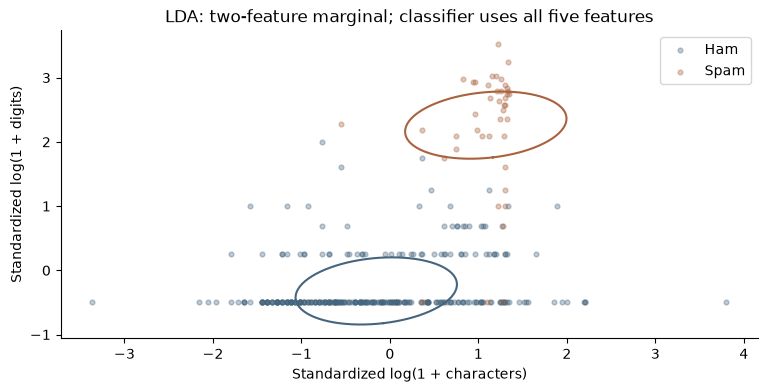

In [30]:
lda_result = lab.lda({})
fig, ax = plt.subplots()
for label, color in [(0, HAM), (1, SPAM)]:
    points = np.asarray([[p["x"], p["y"]] for p in lda_result["points"] if p["label"] == label])
    ax.scatter(points[:, 0], points[:, 1], s=12, alpha=.35, color=color, label="Ham" if label == 0 else "Spam")
    ellipse = np.asarray(lda_result["ellipses"][label])
    ax.plot(ellipse[:, 0], ellipse[:, 1], color=color)
ax.set(xlabel="Standardized log(1 + characters)", ylabel="Standardized log(1 + digits)", title="LDA: two-feature marginal; classifier uses all five features")
ax.legend()
plt.show()

### Try, predict, explain

Compare LDA with logistic regression on the same five features. Which assumption could be wrong here?

In [31]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from experiment import numerical_features

for classifier in [LogisticRegression(solver="liblinear", max_iter=1000, random_state=3612), LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")]:
    model = Pipeline([
        ("features", FunctionTransformer(numerical_features)),
        ("log", FunctionTransformer(np.log1p)),
        ("scale", StandardScaler()),
        ("classifier", classifier)
    ])
    model.fit(X_train, y_train)
    name = "lda" if isinstance(classifier, LinearDiscriminantAnalysis) else "logistic"
    print(name, "validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

logistic validation AP: 0.9453045987771983
lda validation AP: 0.9471988942050922


**Takeaway:** Compare models on the same inputs, so that a difference comes from the model and not the features.

## 13. GAM: Smooth Numerical Effects

**Extension — may be studied separately from the core route.**

Allow curved effects of the log-transformed numerical measurements.

A numerical feature may have a curved effect. This extension builds an additive binomial model with separate spline bases for the five measurements.

- Numerical LR adds a straight-line effect for each standardized log-transformed measurement. A raw character count already has a log transformation in both models.
- Additive model (GAM): each feature adds its own smooth curve fⱼ, built from spline pieces.
- Still additive: no interactions between features.
- Here: sklearn SplineTransformer followed by L2-penalized logistic regression.

### What this implementation means

SplineTransformer constructs separate cubic spline bases for each feature. LogisticRegression then fits a binomial additive model. The basis functions are not interactions.

This is a GAM-style implementation using sklearn, not a dedicated GAM package. Its L2 coefficient penalty is not a derivative-based roughness penalty. Compare it with numerical LR on the same measurements.

### Formula recap

$$\log\frac{p}{1-p}=b+\sum_{j=1}^{5}f_j(x_j),\qquad f_j(x)=\sum_m\beta_{jm}B_{m}(x)$$

- $f_j$: smooth effect of feature j
- $B_m$: cubic spline basis function
- $\beta_{jm}$: fitted coefficients

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, SplineTransformer, StandardScaler
from experiment import numerical_features

for kind in ["logistic", "gam"]:
    steps = [("features", FunctionTransformer(numerical_features)), ("log", FunctionTransformer(np.log1p))]
    if kind == "gam":
        steps.append(("splines", SplineTransformer(n_knots=4, degree=3, include_bias=False)))
    steps += [("scale", StandardScaler()), ("classifier", LogisticRegression(C=1, solver="liblinear", max_iter=1000, random_state=3612))]
    model = Pipeline(steps)
    model.fit(X_train, y_train)
    print(kind, "validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

logistic validation AP: 0.9453045987771983
gam validation AP: 0.9566391488308166


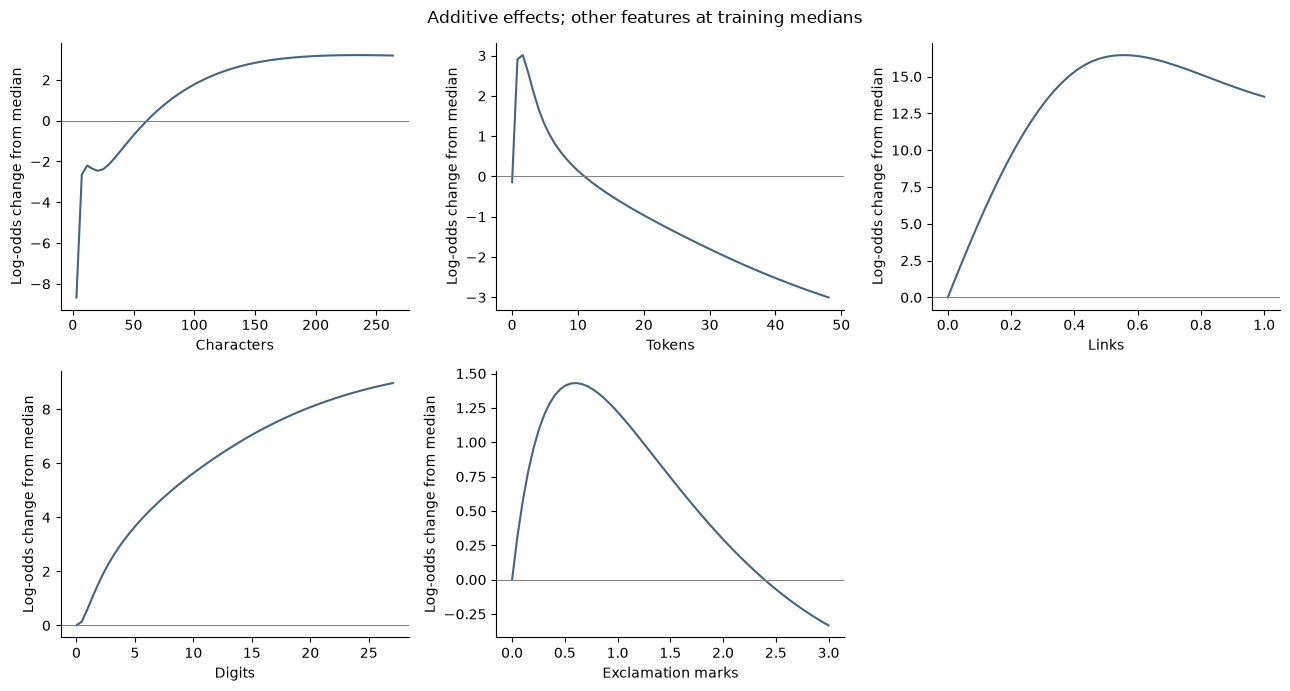

In [33]:
gam_result = lab.gam({"C": 1})
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for item, ax in zip(gam_result["curves"], axes.flat):
    ax.plot(item["x"], item["effect"], color=HAM)
    ax.axhline(0, color="grey", linewidth=.7)
    ax.set(xlabel=item["name"], ylabel="Log-odds change from median")
axes.flat[-1].axis("off")
fig.suptitle("Additive effects; other features at training medians")
plt.tight_layout()
plt.show()

### Try, predict, explain

Find a curve that is clearly not straight. What would one constant weight miss?

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, SplineTransformer, StandardScaler
from experiment import numerical_features

for kind in ["logistic", "gam"]:
    steps = [("features", FunctionTransformer(numerical_features)), ("log", FunctionTransformer(np.log1p))]
    if kind == "gam":
        steps.append(("splines", SplineTransformer(n_knots=4, degree=3, include_bias=False)))
    steps += [("scale", StandardScaler()), ("classifier", LogisticRegression(C=1, solver="liblinear", max_iter=1000, random_state=3612))]
    model = Pipeline(steps)
    model.fit(X_train, y_train)
    print(kind, "validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

logistic validation AP: 0.9453045987771983
gam validation AP: 0.9566391488308166


**Takeaway:** Flexibility can help or overfit. Validation decides.

## 14. Evaluation and Error Analysis

Compare choices fairly, inspect mistakes, then evaluate the selected model.

A useful comparison changes one choice at a time and explains actual mistakes.

- First fix NB and compare counts with TF–IDF. Then fix TF–IDF and compare NB, LR and KNN on the same validation split.
- Precision asks how many flagged messages are spam. Recall asks how much spam is caught. Average precision (AP) summarizes ranking over thresholds; ROC AUC is another ranking summary.
- A threshold turns a model score into a decision. Choose the model and threshold using validation evidence; evaluate the held-out test set once.

### Read the errors in context

A false positive blocks a normal message. A false negative lets spam through. Read examples of both: which words or preprocessing choices might explain the mistake?

All methods here lose some information about language. Historical English SMS results do not establish performance on modern email, Chinese messages or another population.

### If you skipped the extensions

Use the comparison buttons below to build the core candidates directly. Evaluation does not require CV, regularization, LDA or GAM to have been run.

For numerical LDA/GAM comparisons, first filter to numerical runs. Changing both representation and classifier cannot isolate either effect.

### Formula recap

$$\mathrm{Precision}=\frac{TP}{TP+FP},\qquad\mathrm{Recall}=\frac{TP}{TP+FN}$$

- $FP$: normal message blocked
- $FN$: spam missed

### Worked Python example

Read the imports, inputs and intermediate output before modifying the code.

In [35]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from experiment import tokens

# 1. Keep NB fixed; compare representations.
for Vectorizer in [CountVectorizer, TfidfVectorizer]:
    model = Pipeline([
        ("vectorizer", Vectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", MultinomialNB())
    ])
    model.fit(X_train, y_train)
    result = metrics(y_val, model.predict_proba(X_val)[:, 1])
    print("Representation:", Vectorizer.__name__, "NB AP:", round(result["average_precision"], 3))

# 2. Keep TF–IDF fixed; compare classifiers on the same validation messages.
for classifier in [MultinomialNB(), LogisticRegression(solver="liblinear", max_iter=1000, random_state=3612), KNeighborsClassifier(n_neighbors=5, metric="cosine", algorithm="brute")]:
    model = Pipeline([
        ("vectorizer", TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", classifier)
    ])
    model.fit(X_train, y_train)
    result = metrics(y_val, model.predict_proba(X_val)[:, 1])
    print("Classifier:", classifier.__class__.__name__, "AP:", round(result["average_precision"], 3), "precision:", round(result["precision"], 3), "recall:", round(result["recall"], 3))

# Inspect the last classifier’s actual validation decisions.
predicted = model.predict(X_val)
print(classification_report(y_val, predicted, target_names=["ham", "spam"], zero_division=0))
print("Validation confusion matrix:\n", confusion_matrix(y_val, predicted, labels=[0, 1]))

Representation: CountVectorizer NB AP: 0.952
Representation: TfidfVectorizer NB AP: 0.943


Classifier: MultinomialNB AP: 0.943 precision: 1.0 recall: 0.682
Classifier: LogisticRegression AP: 0.958 precision: 1.0 recall: 0.729


Classifier: KNeighborsClassifier AP: 0.899 precision: 0.989 recall: 0.682
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.99      0.68      0.81       129

    accuracy                           0.96      1032
   macro avg       0.97      0.84      0.89      1032
weighted avg       0.96      0.96      0.96      1032

Validation confusion matrix:
 [[902   1]
 [ 41  88]]


### Try, predict, explain

Compare the representations, then the classifiers. Read one false positive and one false negative, justify a model and threshold, and report a data limitation.

In [36]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from experiment import tokens

# 1. Keep NB fixed; compare representations.
for Vectorizer in [CountVectorizer, TfidfVectorizer]:
    model = Pipeline([
        ("vectorizer", Vectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", MultinomialNB())
    ])
    model.fit(X_train, y_train)
    result = metrics(y_val, model.predict_proba(X_val)[:, 1])
    print("Representation:", Vectorizer.__name__, "NB AP:", round(result["average_precision"], 3))

# 2. Keep TF–IDF fixed; compare classifiers on the same validation messages.
for classifier in [MultinomialNB(), LogisticRegression(solver="liblinear", max_iter=1000, random_state=3612), KNeighborsClassifier(n_neighbors=5, metric="cosine", algorithm="brute")]:
    model = Pipeline([
        ("vectorizer", TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", classifier)
    ])
    model.fit(X_train, y_train)
    result = metrics(y_val, model.predict_proba(X_val)[:, 1])
    print("Classifier:", classifier.__class__.__name__, "AP:", round(result["average_precision"], 3), "precision:", round(result["precision"], 3), "recall:", round(result["recall"], 3))

Representation: CountVectorizer NB AP: 0.952
Representation: TfidfVectorizer NB AP: 0.943


Classifier: MultinomialNB AP: 0.943 precision: 1.0 recall: 0.682
Classifier: LogisticRegression AP: 0.958 precision: 1.0 recall: 0.729


Classifier: KNeighborsClassifier AP: 0.899 precision: 0.989 recall: 0.682


**Takeaway:** A score is evidence about this dataset split. Explain the decisions and mistakes behind it.

## Select a candidate and inspect validation errors

The lab helper keeps candidates for the error plots and final test cell, using the same pipelines shown above. The four core candidates below can be fitted without running any extension. You may also select an extension candidate from `lab.runs`. Choose using validation evidence, then write a reason before testing.

run8 nb count validation AP: 0.952
run9 nb tfidf validation AP: 0.943
run10 logistic tfidf validation AP: 0.958
run11 knn tfidf validation AP: 0.899
Selected validation metrics: {'accuracy': 0.9660852713178295, 'precision': 1.0, 'recall': 0.7286821705426356, 'f1': 0.8430493273542601, 'confusion': [[903, 0], [35, 94]], 'false_positive_rate': 0.0, 'log_loss': 0.12778947683055816, 'average_precision': 0.9584667246016647, 'roc_auc': 0.9841098148291225}
True 1 predicted 0 p 0.033 | Hi I'm sue. I am 20 years old and work as a lapdancer. I love sex. Text me live - I'm i my bedroom now. text SUE to 89555. By TextOperator G2 1DA 150ppmsg 18+
True 1 predicted 0 p 0.06 | ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS. I O £250 3 WANT £800
True 1 predicted 0 p 0.06 | Did you hear about the new "Divorce Barbie"? It comes with all of Ken's stuff!
True 1 predicted 0 p 0.062 | Sorry I missed your call let's talk 

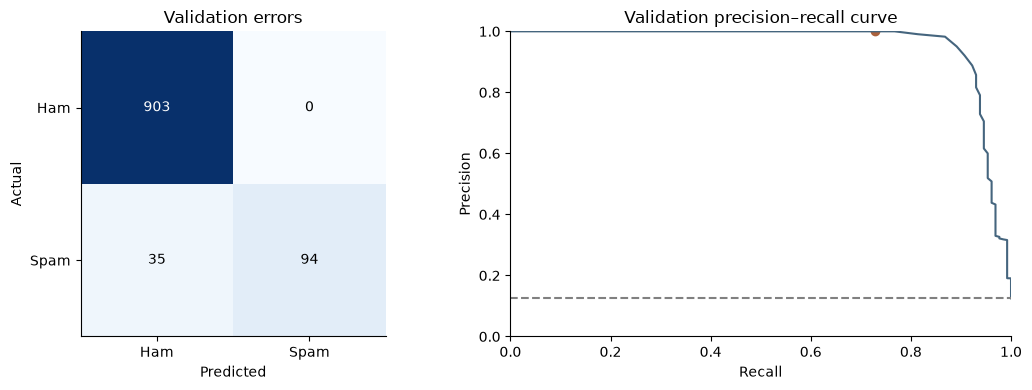

In [37]:
# Each pair changes only the classifier or the representation.
core_candidates = [lab.fit({"kind": kind, "representation": representation})
                   for kind, representation in [("nb", "count"), ("nb", "tfidf"),
                                                 ("logistic", "tfidf"), ("knn", "tfidf")]]
for row in core_candidates:
    print(row["id"], row["kind"], row["representation"], "validation AP:", round(row["validation"]["average_precision"], 3))
selected_id = max(core_candidates, key=lambda row: row["validation"]["average_precision"])["id"]
threshold = .5  # Change only using validation evidence.
validation_result = lab.evaluate({"id": selected_id, "threshold": threshold})
print("Selected validation metrics:", validation_result["metrics"])
for item in validation_result["errors"][:8]:
    print("True", item["label"], "predicted", item["prediction"], "p", round(item["probability"], 3), "|", item["text"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cm = np.asarray(validation_result["metrics"]["confusion"])
axes[0].imshow(cm, cmap="Blues")
for (r, c), value in np.ndenumerate(cm):
    axes[0].text(c, r, str(value), ha="center", va="center", color="white" if value > cm.max() / 2 else "black")
axes[0].set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"], xlabel="Predicted", ylabel="Actual", title="Validation errors")
pr = np.asarray(validation_result["pr"])
axes[1].plot(pr[:, 0], pr[:, 1], color=HAM)
axes[1].axhline(validation_result["prevalence"], ls="--", color="grey")
axes[1].scatter(validation_result["metrics"]["recall"], validation_result["metrics"]["precision"], color=SPAM)
axes[1].set(xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1), title="Validation precision–recall curve")
plt.tight_layout()
plt.show()

## Freeze the decision and evaluate the test set

Explain your representation, classifier and threshold using validation evidence. Include the error tradeoff and a data limitation. This cell runs only when the rationale is nonempty. After testing, the lab freezes the decision. Restarting Python does not make an inspected test set unseen again.

In [38]:
reason = ''  # Write your model and threshold rationale before testing.
if reason.strip():
    final_result = lab.final_test({'id': selected_id, 'threshold': threshold, 'reason': reason})
    print(json.dumps(final_result, indent=2))
else:
    print('Record a rationale above, then run the final test once.')

Record a rationale above, then run the final test once.


## Your experiment record

Report one preprocessing choice, the representation comparison, the classifier comparison, a false positive, a false negative and your final rationale. Include extension experiments if studied.

In [39]:
record = {'dataset': 'Original UCI SMS Spam Collection', 'seed': 3612, 'splits': initial['counts'],
          'runs': [{k: v for k, v in item['row'].items() if k != 'thresholds'} for item in lab.runs.values()],
          'final': lab.final}
print('Recorded candidates:', len(record['runs']))
# Optional: Path('tutorial05-results.json').write_text(json.dumps(record, indent=2))

Recorded candidates: 11


## Appendix: supporting scientific functions

The lesson examples above show the NLTK and sklearn calls directly. These functions are copied from `experiment.py` for readers who want to inspect or modify data loading, measurements and experiment bookkeeping. They are not prerequisites for following the lesson.

In [40]:
import csv
import re
from nltk.tokenize import TreebankWordTokenizer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, log_loss,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, SplineTransformer, StandardScaler
from experiment import SEED, FEATURES

### `tokens`

In [41]:
def tokens(text):
    """NLTK splits punctuation; retain alphanumeric tokens for this baseline."""
    return [word for word in TreebankWordTokenizer().tokenize(text.lower())
            if word.isalnum()]

### `text_vectorizer`

In [42]:
def text_vectorizer(representation='count', **options):
    """Use the SAME NLTK preprocessing in toy examples and real classifiers."""
    vectorizer = CountVectorizer if representation == 'count' else TfidfVectorizer
    return vectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, **options)

### `numerical_features`

In [43]:
def numerical_features(messages):
    """Hand-designed observations; no labels or fitted statistics are used."""
    return np.asarray([[len(s), len(tokens(s)),
                        len(re.findall(r'https?://|www\.', s, flags=re.I)),
                        sum(c.isdigit() for c in s), s.count('!')]
                       for s in messages], dtype=float)

### `load_data`

In [44]:
def load_data(path):
    """Deduplicate message identities BEFORE splitting; reject label conflicts."""
    with open(path, encoding='utf-8-sig', newline='') as handle:
        rows = list(csv.DictReader(handle, fieldnames=['Category', 'Message'],
                                   delimiter='\t', quoting=csv.QUOTE_NONE))
    unique = {}
    excluded = 0
    for row in rows:
        text, category = row['Message'], row['Category']
        if category not in ('ham', 'spam'):
            raise ValueError('Expected ham/spam Category.')
        if not text.strip() or text.strip() == '#ERROR!':
            excluded += 1
            continue
        # Identical after whitespace/case normalization must not cross splits.
        identity = ' '.join(text.lower().split())
        label = int(category == 'spam')
        if identity in unique and unique[identity][1] != label:
            raise ValueError('Conflicting labels for the same message.')
        unique.setdefault(identity, (text, label))
    messages = np.asarray([r[0] for r in unique.values()])
    labels = np.asarray([r[1] for r in unique.values()], dtype=int)
    train_val, test = train_test_split(np.arange(len(labels)), test_size=.2,
                                      stratify=labels, random_state=SEED)
    train, validation = train_test_split(train_val, test_size=.25,
                                       stratify=labels[train_val], random_state=SEED)
    return messages, labels, {'train': train, 'validation': validation, 'test': test}, {'raw': len(rows), 'excluded': excluded}

### `decision_metrics`

In [45]:
def decision_metrics(y, probability, threshold=.5):
    """Threshold-dependent decisions, computed once in the scientific layer."""
    p = np.asarray(probability, dtype=float)
    prediction = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, prediction, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if tp + fp else 0.
    recall = tp / (tp + fn) if tp + fn else 0.
    return {'accuracy': float((prediction == y).mean()), 'precision': float(precision),
            'recall': float(recall), 'f1': float(2 * precision * recall / (precision + recall))
            if precision + recall else 0., 'confusion': [[int(tn), int(fp)], [int(fn), int(tp)]],
            'false_positive_rate': float(fp / (tn + fp)) if tn + fp else 0.}

### `metrics`

In [46]:
def metrics(y, probability, threshold=.5):
    """Positive class is spam. Undefined precision is reported as zero."""
    p = np.asarray(probability, dtype=float)
    return {**decision_metrics(y, p, threshold),
            'log_loss': float(log_loss(y, np.clip(p, 1e-12, 1 - 1e-12), labels=[0, 1])),
            'average_precision': float(average_precision_score(y, p)),
            'roc_auc': float(roc_auc_score(y, p))}

### `build_model`

In [47]:
def build_model(kind='logistic', representation='count', C=1., k=5, alpha=1.):
    """Keep every learned transformation inside the pipeline."""
    if kind not in ('logistic', 'nb', 'knn', 'lda', 'gam'):
        raise ValueError('Unknown model.')
    if representation not in ('count', 'tfidf', 'numeric'):
        raise ValueError('Unknown representation.')
    if kind == 'nb' and (representation == 'numeric' or alpha <= 0):
        raise ValueError('Naive Bayes needs nonnegative text features and alpha > 0.')
    if representation == 'numeric' or kind in ('lda', 'gam'):
        steps = [('features', FunctionTransformer(numerical_features)),
                 ('log', FunctionTransformer(np.log1p))]
        if kind == 'gam':
            # Separate spline bases for each input; no feature interactions.
            steps += [('splines', SplineTransformer(n_knots=4, degree=3,
                                                    include_bias=False))]
        steps += [('scale', StandardScaler())]
    else:
        steps = [('vectorizer', text_vectorizer(representation, min_df=2,
                                               max_features=2500))]
    if kind == 'lda':
        classifier = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    elif kind == 'knn':
        classifier = KNeighborsClassifier(n_neighbors=int(k), algorithm='brute',
                                           metric='euclidean' if representation == 'numeric' else 'cosine')
    elif kind == 'nb':
        classifier = MultinomialNB(alpha=float(alpha))
    else:
        classifier = LogisticRegression(C=float(C), solver='liblinear', max_iter=1000,
                                         random_state=SEED)
    return Pipeline(steps + [('classifier', classifier)])

### `cross_validate`

In [48]:
def cross_validate(messages, labels, representation='count', values=(.01, .1, 1., 10.)):
    """Fit vocabulary, IDF and model afresh inside EACH training fold."""
    folds = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(messages, labels))
    rows = []
    for C in values:
        scores, training, vocabulary_sizes = [], [], []
        for train, heldout in folds:
            model = build_model(C=C, representation=representation)
            model.fit(messages[train], labels[train])
            scores.append(average_precision_score(labels[heldout], model.predict_proba(messages[heldout])[:, 1]))
            training.append(average_precision_score(labels[train], model.predict_proba(messages[train])[:, 1]))
            vocabulary_sizes.append(len(model.named_steps['vectorizer'].vocabulary_))
        rows.append({'C': C, 'folds': list(map(float, scores)), 'train': float(np.mean(training)),
                     'mean': float(np.mean(scores)), 'std': float(np.std(scores, ddof=1)),
                     'vocabulary_sizes': vocabulary_sizes})
    return rows